<a href="https://colab.research.google.com/github/JarrarH/CIFAR-100-CNN-Image-Classification/blob/main/Project_CIFER_100.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [39]:
from tensorflow.keras.datasets import cifar100

(x_train, y_train), (x_test, y_test) = cifar100.load_data()

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 1923s 11us/step


In [40]:
print(x_train.shape)
print(y_train.shape)

print(x_test.shape)
print(y_test.shape)

(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)
(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


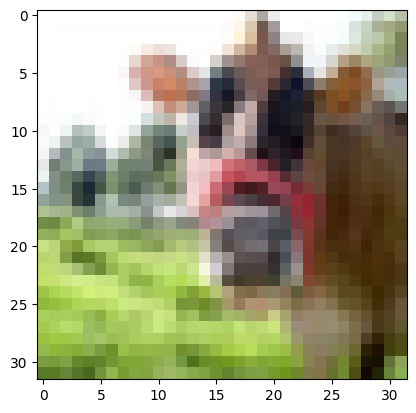

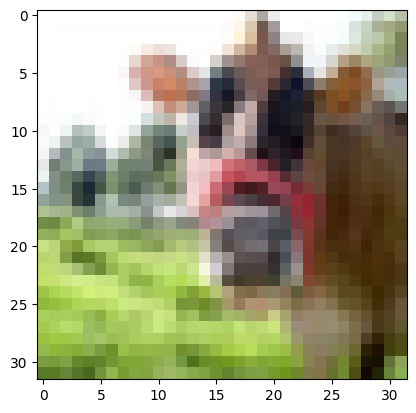

In [41]:
import matplotlib.pyplot as plt

plt.imshow(x_train[0])
plt.show()

In [42]:
print(x_train[0])

[[[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [195 205 193]
  [212 224 204]
  [182 194 167]]

 [[255 255 255]
  [254 254 254]
  [254 254 254]
  ...
  [170 176 150]
  [161 168 130]
  [146 154 113]]

 [[255 255 255]
  [254 254 254]
  [255 255 255]
  ...
  [189 199 169]
  [166 178 130]
  [121 133  87]]

 ...

 [[148 185  79]
  [142 182  57]
  [140 179  60]
  ...
  [ 30  17   1]
  [ 65  62  15]
  [ 76  77  20]]

 [[122 157  66]
  [120 155  58]
  [126 160  71]
  ...
  [ 22  16   3]
  [ 97 112  56]
  [141 161  87]]

 [[ 87 122  41]
  [ 88 122  39]
  [101 134  56]
  ...
  [ 34  36  10]
  [105 133  59]
  [138 173  79]]]
[[[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [195 205 193]
  [212 224 204]
  [182 194 167]]

 [[255 255 255]
  [254 254 254]
  [254 254 254]
  ...
  [170 176 150]
  [161 168 130]
  [146 154 113]]

 [[255 255 255]
  [254 254 254]
  [255 255 255]
  ...
  [189 199 169]
  [166 178 130]
  [121 133  87]]

 ...

 [[148 185  79]
  [142 182  57]
  [140 179  60]
  ..

In [43]:
print(y_train[0])

[19]
[19]


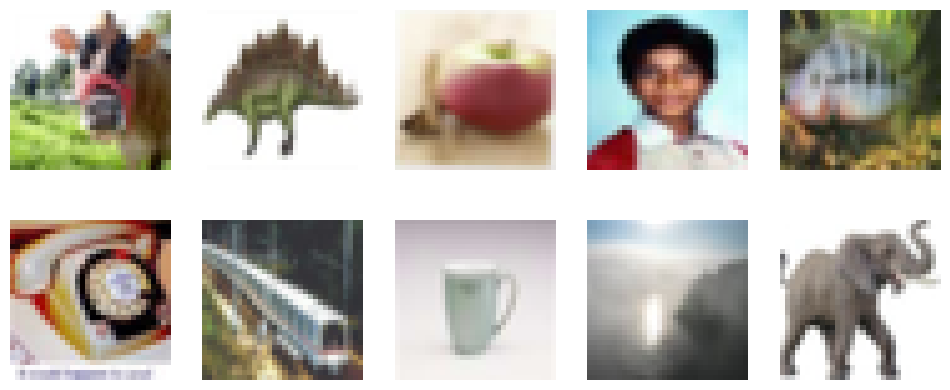

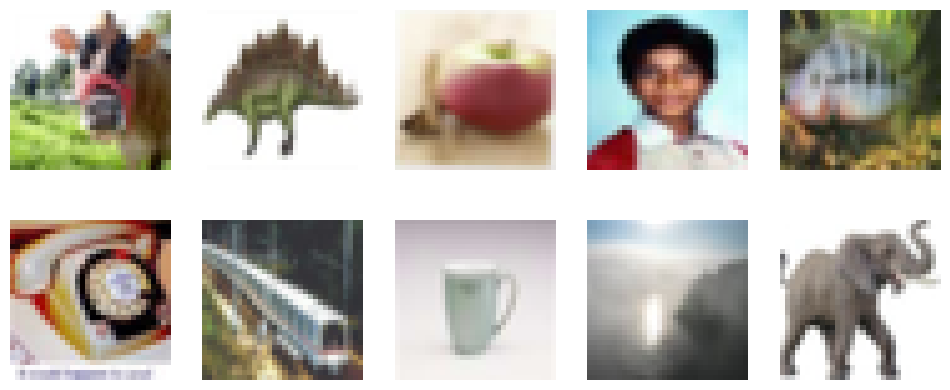

In [44]:
plt.figure(figsize=(12,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.axis("off")

plt.show()

In [45]:
print(x_train.dtype)
print(x_train.min())
print(x_train.max())

uint8
0
255
uint8
0
255


In [46]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [47]:
print(x_train.dtype)
print(x_train.min())
print(x_train.max())

float32
0.0
1.0
float32
0.0
1.0


In [48]:
print(y_train[:10])

[[19]
 [29]
 [ 0]
 [11]
 [ 1]
 [86]
 [90]
 [28]
 [23]
 [31]]
[[19]
 [29]
 [ 0]
 [11]
 [ 1]
 [86]
 [90]
 [28]
 [23]
 [31]]


In [49]:
print(y_train.shape)

(50000, 1)
(50000, 1)


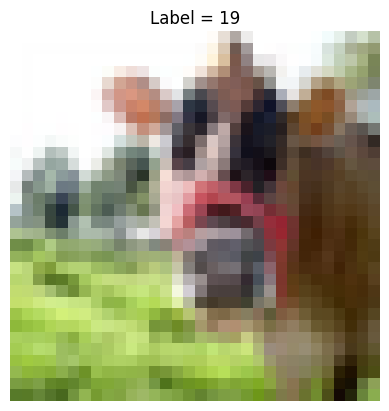

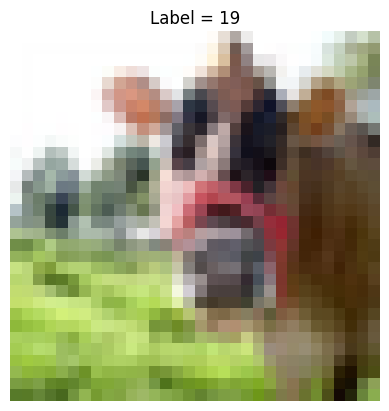

In [50]:
plt.imshow(x_train[0])
plt.title(f"Label = {y_train[0][0]}")
plt.axis("off")
plt.show()

In [51]:
from tensorflow.keras.models import Sequential

In [52]:
model = Sequential()

In [53]:
from tensorflow.keras.layers import Conv2D

In [54]:
model.add(
    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation="relu",
        input_shape=(32,32,3)
    )
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [55]:
print(x_train.shape)

(50000, 32, 32, 3)
(50000, 32, 32, 3)


In [56]:
from tensorflow.keras.layers import MaxPooling2D
model.add(
    MaxPooling2D(
        pool_size=(2,2)
    )
)

In [57]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896 (3.50 KB)

 Trainable params: 896 (3.50 KB)

 Non-trainable params: 0 (0.00 B)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896 (3.50 KB)

 Trainable params: 896 (3.50 KB)

 Non-trainable params: 0 (0.00 B)

In [58]:
model.add(
    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation="relu"
    )
)

In [59]:
model.add(
    MaxPooling2D(pool_size=(2,2))
)

In [60]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,392 (75.75 KB)

 Trainable params: 19,392 (75.75 KB)

 Non-trainable params: 0 (0.00 B)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,392 (75.75 KB)

 Trainable params: 19,392 (75.75 KB)

 Non-trainable params: 0 (0.00 B)

In [61]:
from tensorflow.keras.layers import Flatten
model.add(
    Flatten()
)

In [62]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,392 (75.75 KB)

 Trainable params: 19,392 (75.75 KB)

 Non-trainable params: 0 (0.00 B)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2304)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,392 (75.75 KB)

 Trainable params: 19,392 (75.75 KB)

 Non-trainable params: 0 (0.00 B)

In [63]:
from tensorflow.keras.layers import Dense

model.add(
    Dense(
        units=128,
        activation="relu"
    )
)

In [64]:
model.add(
    Dense(
        units=100,
        activation="softmax"
    )
)

In [65]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        12,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 327,332 (1.25 MB)

 Trainable params: 327,332 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 100)            │        12,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 327,332 (1.25 MB)

 Trainable params: 327,332 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

In [66]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [67]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(x_test, y_test)
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.1418 - loss: 3.7078 - val_accuracy: 0.2314 - val_loss: 3.1751
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.2735 - loss: 2.9656 - val_accuracy: 0.2797 - val_loss: 2.9108
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.3308 - loss: 2.6650 - val_accuracy: 0.3334 - val_loss: 2.6900
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.3725 - loss: 2.4688 - val_accuracy: 0.3459 - val_loss: 2.5960
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.4019 - loss: 2.3253 - val_accuracy: 0.3566 - val_loss: 2.5836
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.4268 - loss: 2.2048 - val_accuracy: 0.3538 - val_loss: 2.5890
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4515 - loss: 2.0968 - val_accuracy: 0.3722 - val_loss: 2.5566
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.4732 - loss: 1.9999 -

 Improved CNN Architecture
# (Version 2)
Previous model showed signs of overfitting.

In [68]:
from tensorflow.keras.layers import Dropout

In [69]:


model_v2 = Sequential()

# First Convolution Block
model_v2.add(Conv2D(32, (3,3), activation="relu", input_shape=(32,32,3)))
model_v2.add(Conv2D(32, (3,3), activation="relu"))
model_v2.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Block
model_v2.add(Conv2D(64, (3,3), activation="relu"))
model_v2.add(Conv2D(64, (3,3), activation="relu"))
model_v2.add(MaxPooling2D(pool_size=(2,2)))

# Flatten
model_v2.add(Flatten())

# Hidden Layer
model_v2.add(Dense(256, activation="relu"))

# Reduce Overfitting
model_v2.add(Dropout(0.5))

# Output Layer
model_v2.add(Dense(100, activation="softmax"))

In [70]:
model_v2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [71]:
model_v2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 10, 10, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       409,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 501,124 (1.91 MB)

 Trainable params: 501,124 (1.91 MB)

 Non-trainable params: 0 (0.00 B)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 10, 10, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       409,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 501,124 (1.91 MB)

 Trainable params: 501,124 (1.91 MB)

 Non-trainable params: 0 (0.00 B)

In [72]:
history_v2 = model_v2.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(x_test, y_test)
)

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.0727 - loss: 4.0846 - val_accuracy: 0.1502 - val_loss: 3.6234
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.1607 - loss: 3.5357 - val_accuracy: 0.2296 - val_loss: 3.2018
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.2101 - loss: 3.2657 - val_accuracy: 0.2643 - val_loss: 3.0134
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.2409 - loss: 3.0929 - val_accuracy: 0.2848 - val_loss: 2.9017
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.2698 - loss: 2.9514 - val_accuracy: 0.3057 - val_loss: 2.8317
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.2871 - loss: 2.8489 - val_accuracy: 0.3098 - val_loss: 2.7904
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.3059 - loss: 2.7539 - val_accuracy: 0.3250 - val_loss: 2.7066
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.3216 - loss: 2.6728

In [73]:
model_v2.save("cnn_model_v2.keras")

In [74]:
from tensorflow.keras.models import load_model

model_v2 = load_model("cnn_model_v2.keras")

# Improved CNN Architecture (Version 3)

The previous CNN model achieved a validation accuracy of around 37%.
To further improve the model's ability to generalize, Version 3 introduces
data augmentation, batch normalization, additional convolutional layers,
and improved regularization.

In [75]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dropout,
    Dense,
    GlobalAveragePooling2D
)
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomTranslation
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

In [76]:
data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.05),
    RandomTranslation(0.1, 0.1)
])

In [77]:
model_v3 = Sequential()

# Data Augmentation
model_v3.add(data_augmentation)

# First Convolution Block
model_v3.add(Conv2D(32, (3,3), padding="same", activation="relu", input_shape=(32,32,3)))
model_v3.add(BatchNormalization())
model_v3.add(Conv2D(32, (3,3), padding="same", activation="relu"))
model_v3.add(BatchNormalization())
model_v3.add(MaxPooling2D(pool_size=(2,2)))
model_v3.add(Dropout(0.25))

# Second Convolution Block
model_v3.add(Conv2D(64, (3,3), padding="same", activation="relu"))
model_v3.add(BatchNormalization())
model_v3.add(Conv2D(64, (3,3), padding="same", activation="relu"))
model_v3.add(BatchNormalization())
model_v3.add(MaxPooling2D(pool_size=(2,2)))
model_v3.add(Dropout(0.30))

# Third Convolution Block
model_v3.add(Conv2D(128, (3,3), padding="same", activation="relu"))
model_v3.add(BatchNormalization())
model_v3.add(Conv2D(128, (3,3), padding="same", activation="relu"))
model_v3.add(BatchNormalization())
model_v3.add(MaxPooling2D(pool_size=(2,2)))
model_v3.add(Dropout(0.35))

# Global Average Pooling
model_v3.add(GlobalAveragePooling2D())

# Fully Connected Layer
model_v3.add(Dense(256, activation="relu"))
model_v3.add(BatchNormalization())
model_v3.add(Dropout(0.5))

# Output Layer
model_v3.add(Dense(100, activation="softmax"))

In [79]:
model_v3.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_v3.build(input_shape=(None, 32, 32, 3))
model_v3.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 348,548 (1.33 MB)

 Trainable params: 347,140 (1.32 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [80]:
callbacks_v3 = [
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),

    EarlyStopping(
        monitor="val_accuracy",
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),

    ModelCheckpoint(
        "cnn_model_v3_best.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]

In [81]:
history_v3 = model_v3.fit(
    x_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(x_test, y_test),
    callbacks=callbacks_v3
)

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.0519 - loss: 4.5689
Epoch 1: val_accuracy improved from None to 0.16420, saving model to cnn_model_v3_best.keras

Epoch 1: finished saving model to cnn_model_v3_best.keras
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 19ms/step - accuracy: 0.0793 - loss: 4.1805 - val_accuracy: 0.1642 - val_loss: 3.5227 - learning_rate: 0.0010
Epoch 2/50
1562/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1522 - loss: 3.5453
Epoch 2: val_accuracy improved from 0.16420 to 0.19110, saving model to cnn_model_v3_best.keras

Epoch 2: finished saving model to cnn_model_v3_best.keras
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.1713 - loss: 3.4354 - val_accuracy: 0.1911 - val_loss: 3.5402 - learning_rate: 0.0010
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2168 - loss: 3.1633
Epoch 3: val_accuracy improved from 0.19110 to 0.28100, saving model to cnn_model_v3_best.keras

Epoch 3: finished saving model to cnn_m

In [82]:
from tensorflow.keras.models import load_model

best_model_v3 = load_model("cnn_model_v3_best.keras")

test_loss_v3, test_accuracy_v3 = best_model_v3.evaluate(
    x_test,
    y_test,
    verbose=1
)

print(f"V3 Test Accuracy: {test_accuracy_v3 * 100:.2f}%")
print(f"V3 Test Loss: {test_loss_v3:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5510 - loss: 1.6528
V3 Test Accuracy: 55.10%
V3 Test Loss: 1.6528


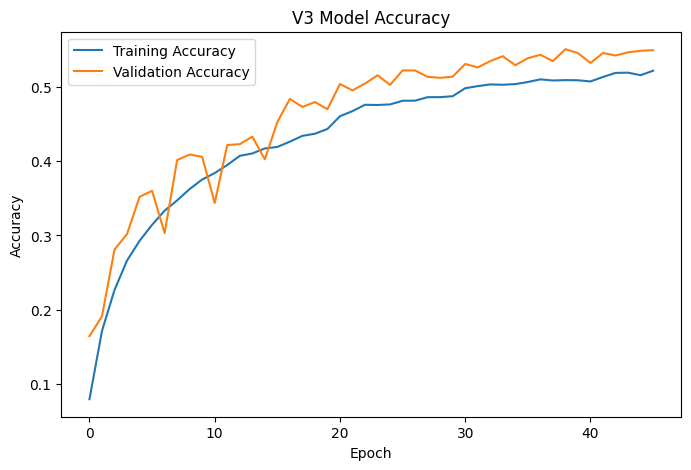

In [84]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history_v3.history["accuracy"], label="Training Accuracy")
plt.plot(history_v3.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("V3 Model Accuracy")
plt.legend()
plt.show()

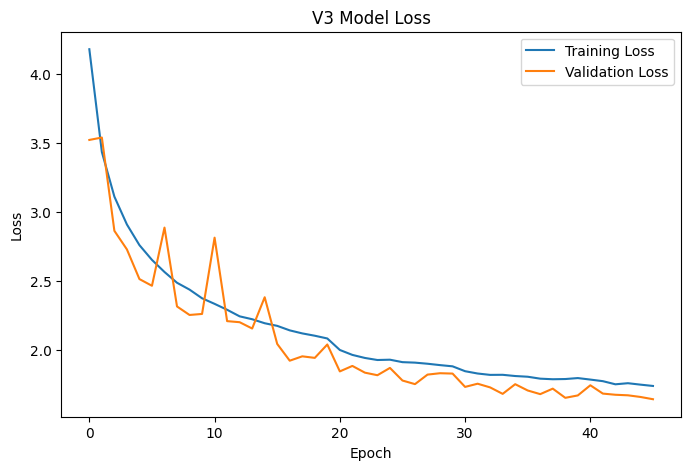

In [85]:
plt.figure(figsize=(8, 5))
plt.plot(history_v3.history["loss"], label="Training Loss")
plt.plot(history_v3.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("V3 Model Loss")
plt.legend()
plt.show()

In [86]:
# Evaluate the original V2 model
v2_loss, v2_accuracy = model_v2.evaluate(
    x_test,
    y_test,
    verbose=0
)

print(f"V2 Accuracy: {v2_accuracy * 100:.2f}%")
print(f"V3 Accuracy: {test_accuracy_v3 * 100:.2f}%")
print(f"Improvement: {(test_accuracy_v3 - v2_accuracy) * 100:.2f} percentage points")

V2 Accuracy: 37.48%
V3 Accuracy: 55.10%
Improvement: 17.62 percentage points


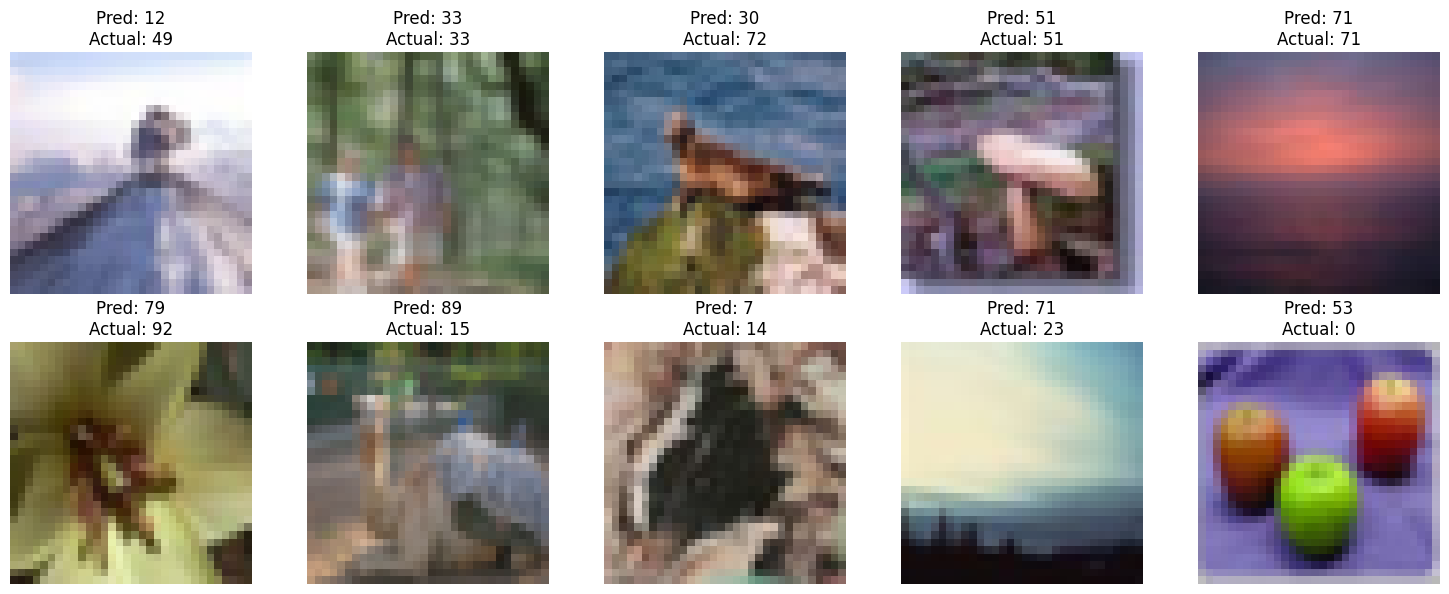

In [89]:
predictions_v3 = best_model_v3.predict(x_test[:10], verbose=0)
predicted_classes = np.argmax(predictions_v3, axis=1)

plt.figure(figsize=(15, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i])
    plt.title(
        f"Pred: {predicted_classes[i]}\nActual: {y_test[i][0]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

In [88]:
cifar100_classes = [
    "apple", "aquarium_fish", "baby", "bear", "beaver",
    "bed", "bee", "beetle", "bicycle", "bottle",
    "bowl", "boy", "bridge", "bus", "butterfly",
    "camel", "can", "castle", "caterpillar", "cattle",
    "chair", "chimpanzee", "clock", "cloud", "cockroach",
    "couch", "crab", "crocodile", "cup", "dinosaur",
    "dolphin", "elephant", "flatfish", "forest", "fox",
    "girl", "hamster", "house", "kangaroo", "keyboard",
    "lamp", "lawn_mower", "leopard", "lion", "lizard",
    "lobster", "man", "maple_tree", "motorcycle", "mountain",
    "mouse", "mushroom", "oak_tree", "orange", "orchid",
    "otter", "palm_tree", "pear", "pickup_truck", "pine_tree",
    "plain", "plate", "poppy", "porcupine", "possum",
    "rabbit", "raccoon", "ray", "road", "rocket",
    "rose", "sea", "seal", "shark", "shrew",
    "skunk", "skyscraper", "snail", "snake", "spider",
    "squirrel", "streetcar", "sunflower", "sweet_pepper",
    "table", "tank", "telephone", "television", "tiger",
    "tractor", "train", "trout", "tulip", "turtle",
    "wardrobe", "whale", "willow_tree", "wolf", "woman",
    "worm"
]

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step


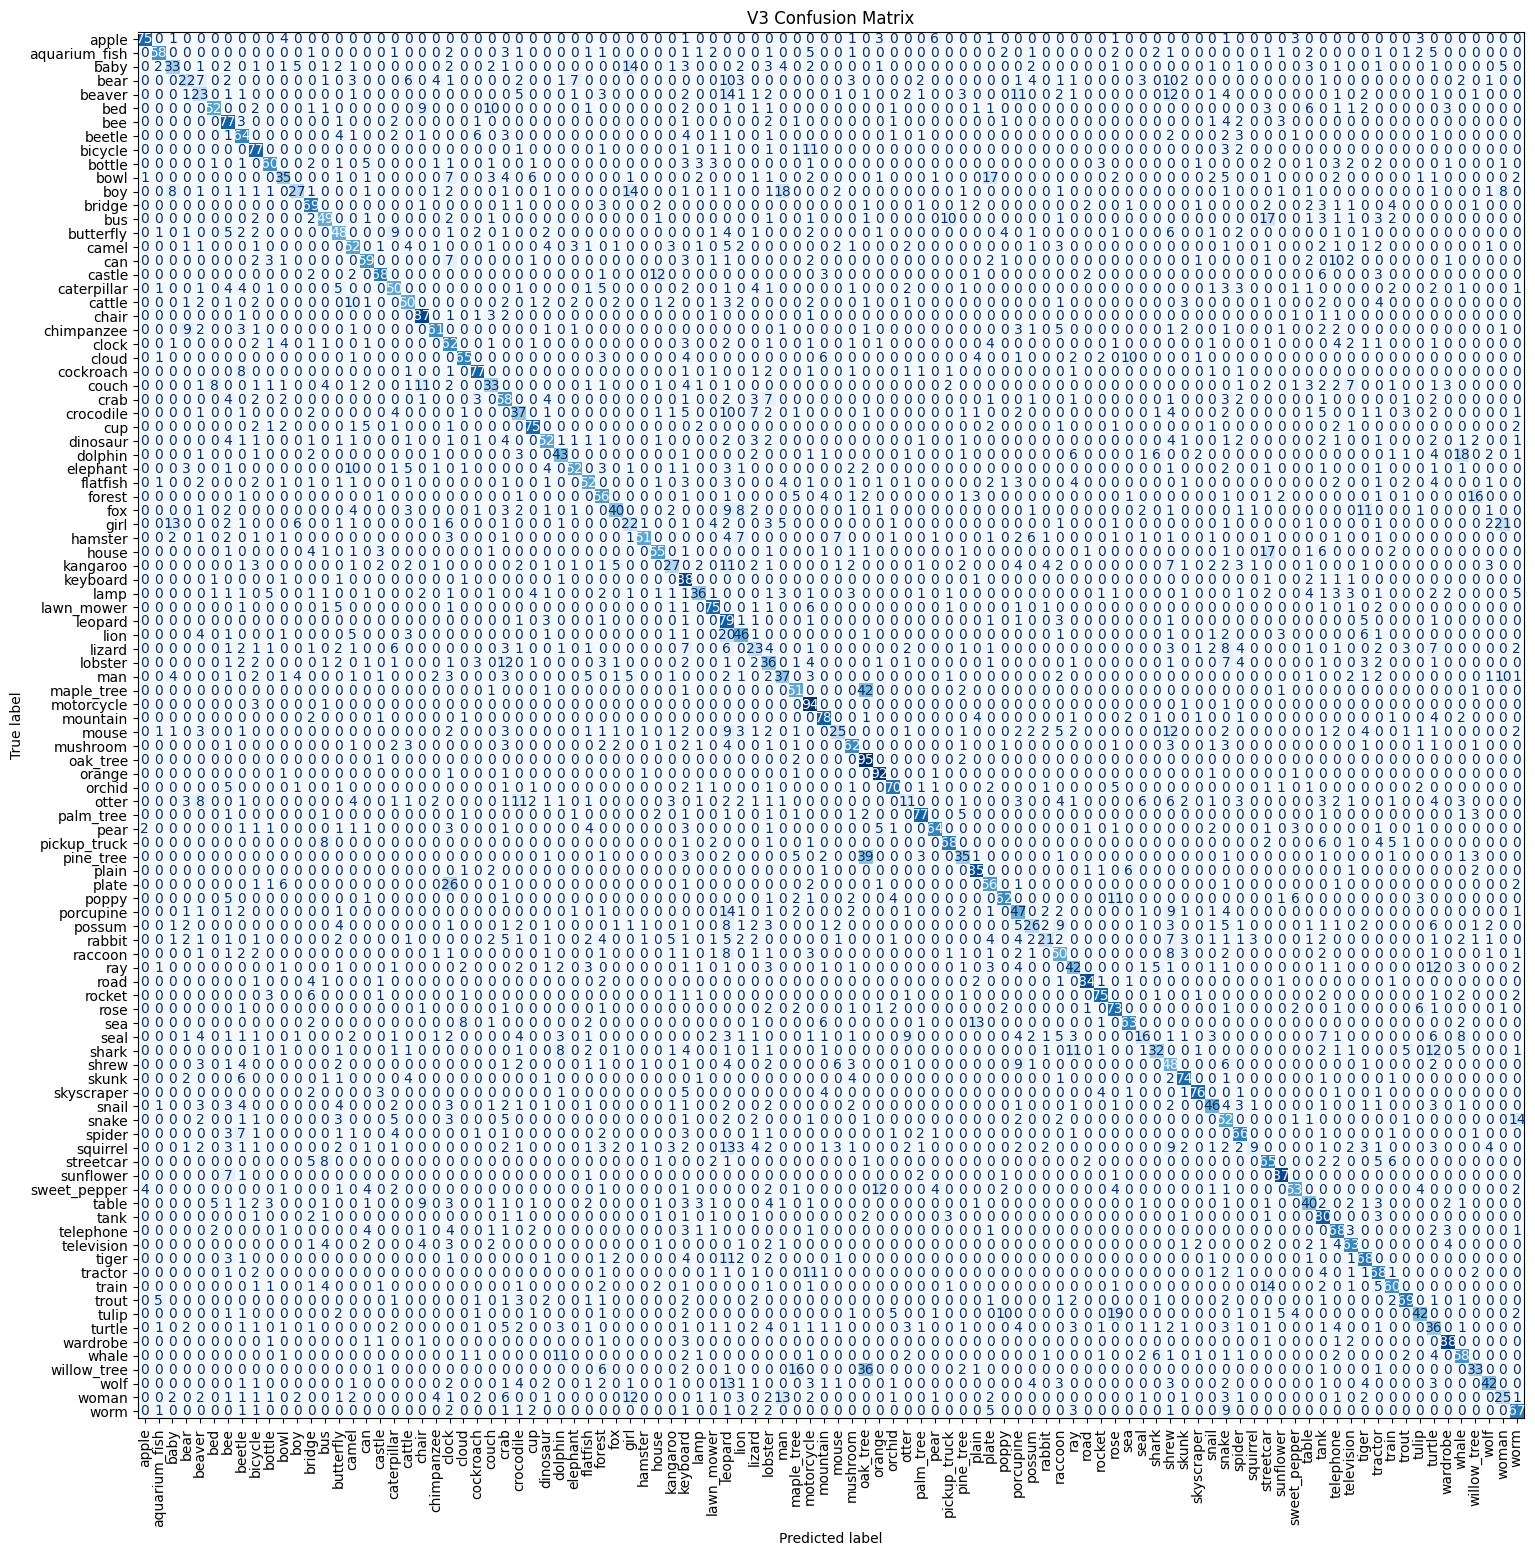

In [90]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get predictions for the complete test set
y_pred_probs = best_model_v3.predict(x_test, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

# Convert true labels to 1D
y_true = y_test.flatten()

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(18, 18))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=cifar100_classes
)

disp.plot(
    xticks_rotation=90,
    ax=plt.gca(),
    cmap="Blues",
    colorbar=False
)

plt.title("V3 Confusion Matrix")
plt.show()

In [91]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(
    y_true,
    y_pred,
    target_names=cifar100_classes,
    output_dict=True,
    zero_division=0
)

class_results = pd.DataFrame(report).T

# Remove overall averages
class_results = class_results.iloc[:100]

# Sort by F1-score
best_classes = class_results.sort_values(
    "f1-score",
    ascending=False
).head(10)

worst_classes = class_results.sort_values(
    "f1-score",
    ascending=True
).head(10)

print("Top 10 Performing Classes:")
display(best_classes[["precision", "recall", "f1-score"]])

print("\nBottom 10 Performing Classes:")
display(worst_classes[["precision", "recall", "f1-score"]])

Top 10 Performing Classes:


,precision,recall,f1-score
road,0.893617,0.84,0.865979
wardrobe,0.822430,0.88,0.850242
sunflower,0.813084,0.87,0.840580
orange,0.760331,0.92,0.832579
apple,0.914634,0.75,0.824176
skyscraper,0.853933,0.76,0.804233
rocket,0.824176,0.75,0.785340
palm_tree,0.793814,0.77,0.781726
plain,0.708333,0.85,0.772727
chair,0.679688,0.87,0.763158



Bottom 10 Performing Classes:


,precision,recall,f1-score
otter,0.250000,0.11,0.152778
squirrel,0.600000,0.09,0.156522
seal,0.421053,0.16,0.231884
lizard,0.280488,0.23,0.252747
girl,0.301370,0.22,0.254335
beaver,0.291139,0.23,0.256983
bear,0.423077,0.22,0.289474
woman,0.347222,0.25,0.290698
turtle,0.250000,0.36,0.295082
rabbit,0.538462,0.21,0.302158


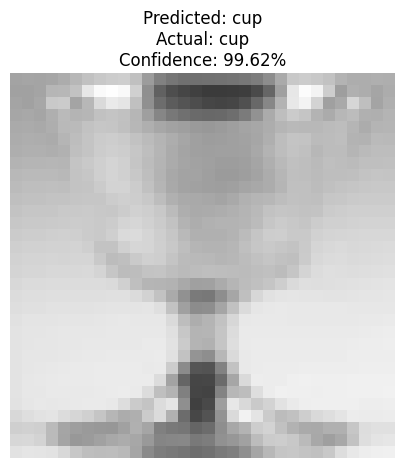

In [92]:
import numpy as np
import matplotlib.pyplot as plt

# Select one random test image
random_index = np.random.randint(0, len(x_test))

image = x_test[random_index]
actual_class = y_test[random_index][0]

# Predict
prediction = best_model_v3.predict(
    np.expand_dims(image, axis=0),
    verbose=0
)

predicted_class = np.argmax(prediction[0])
confidence = np.max(prediction[0]) * 100

# Display
plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.title(
    f"Predicted: {cifar100_classes[predicted_class]}\n"
    f"Actual: {cifar100_classes[actual_class]}\n"
    f"Confidence: {confidence:.2f}%"
)
plt.axis("off")
plt.show()